# Load libraries

In [1]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate, visualise_weights

# Modelling

In [2]:
# ZDT calling
linear_model = LinearModel(problem = ZDT1(n_dim = 10), max_iter = 10, random_state = 42)
choquet_model = ChoquetModel(problem = ZDT1(n_dim = 10), max_iter = 10, random_state = 42, method = 2)

# DTLZ calling
# linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42)
# choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape}  PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape} PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (174, 2)  PS (174, 10)
ChoquetModel:  PF (150, 2) PS (150, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,4.574002,1364,174,10,0.107959
ChoquetModel,4.587809,1694,150,10,1.254244


# Model visualisation

In [3]:
# for kind in ["symmetric", "absolute", "norm"]:
#     visualise_weights(choquet_model, kind = kind);

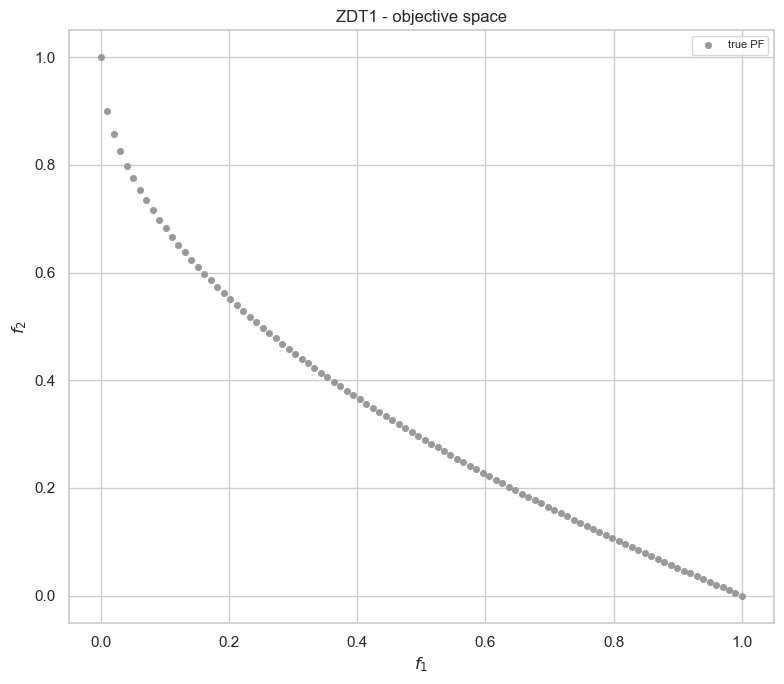

In [4]:
linear_model.visualise("true_pf");

## Linear Model

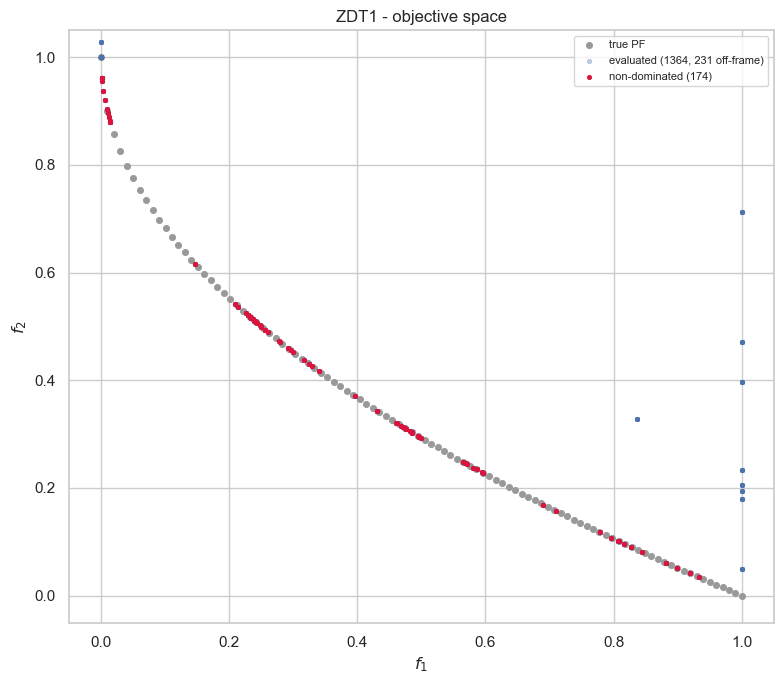

In [5]:
linear_model.visualise("objective");

In [6]:
linear_model.visualise("learning", show = False)

In [7]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [8]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

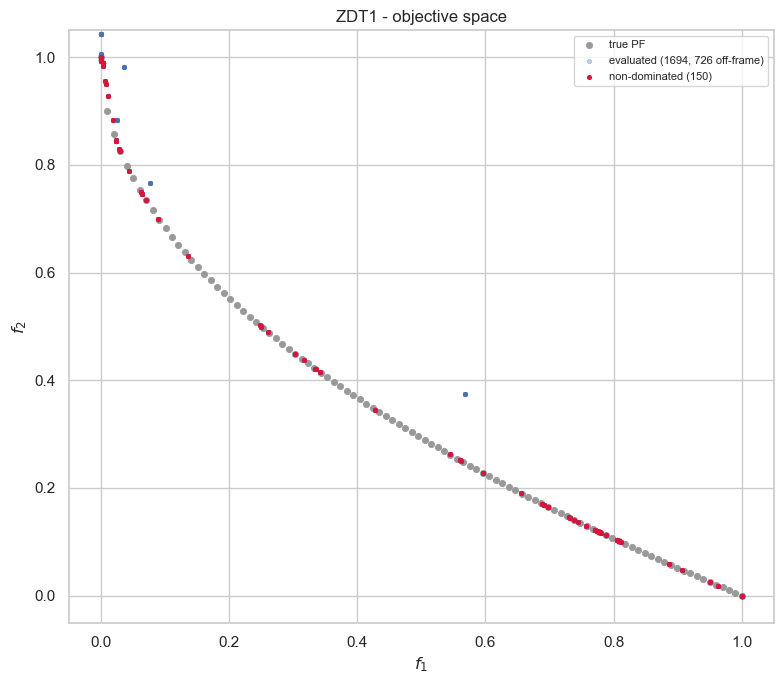

In [9]:
choquet_model.visualise("objective");

In [10]:
choquet_model.visualise("learning", show = False)

In [11]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [12]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 15
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(2.6)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(2.5)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.0), 'ChoquetModel': np.float64(1.8)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(1.0)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(2.0)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.5), 'ChoquetModel': np.float64(2.9)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.9)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(2.1)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(3.7)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(28.5)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(1.8)}
DTLZ1 n_dim=20 n_obj=3 {'L

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                      
DTLZ1   10    2     ChoquetModel  1.950435e+05         1485               20   
                    LinearModel   2.061301e+05         1518               14   
              3     ChoquetModel  7.320898e+07         1672               92   
                    LinearModel   7.324683e+07         1364               72   
              4     ChoquetModel  3.111752e+09         2112              316   
                    LinearModel   3.120221e+09         1573               74   
              5     ChoquetModel  2.361383e+11         5093              933   
                    LinearModel   2.270040e+11         1683              233   
        20    2     ChoquetModel  2.029089e+06         5271              117   
                    LinearModel   1.976071e+06         2898               47   
              3     ChoquetModel  7.461355e+08         4221              214   
                    LinearModel   7.396853e+08         2814               63   
              4     ChoquetModel  4.193646e+11         7791              692   
                    LinearModel   4.089682e+11         2961              149   
              5     ChoquetModel  7.050059e+13         9786              993   
                    LinearModel   6.976790e+13         2625              109   
DTLZ2   10    2     ChoquetModel  2.046189e+00         1056               27   
                    LinearModel   1.559818e+00          770                4   
              3     ChoquetModel  1.118617e+01         1771               62   
                    LinearModel   1.145768e+01          572                6   
              4     ChoquetModel  1.231599e+01          913               33   
                    LinearModel   1.275134e+01          913               31   
              5     ChoquetModel  1.866185e+01         1562              111   
                    LinearModel   1.853793e+01          869               51   
        20    2     ChoquetModel  1.017483e+01         1407                4   
                    LinearModel   1.089034e+01         1533                5   
              3     ChoquetModel  4.236941e+01         1554               49   
                    LinearModel   4.003263e+01         1176                9   
              4     ChoquetModel  1.179948e+02         3066               15   
                    LinearModel   8.429362e+01         1323                5   
              5     ChoquetModel  1.822407e+02         2793              130   
                    LinearModel   1.397679e+02          966               11   
ZDT1    10    2     ChoquetModel  4.595246e+00         2068              202   
                    LinearModel   4.595124e+00         1870              242   
        20    2     ChoquetModel  4.613655e+00         2961              188   
                    LinearModel   4.703539e+00         3633              208   
ZDT2    10    2     ChoquetModel  5.424551e+00         1562              187   
                    LinearModel   5.228026e+00          539                9   
        20    2     ChoquetModel  5.181550e+00         1659               35   
                    LinearModel   4.971102e+00         1554                3   
ZDT3    10    2     ChoquetModel  6.002382e+00         1507               92   
                    LinearModel   5.146217e+00         3410                2   
        20    2     ChoquetModel  5.392725e+00         6615              157   
                    LinearModel   5.606733e+00         6384              166   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      15        0.852086  
                    LinearModel       15        0.098202  
              3     ChoquetModel      15        2.145285  
                    LinearModel       15        0.100946  


In [13]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel   LinearModel        winner  gap_pct
problem n_dim n_obj                                                   
DTLZ1   10    2      1.950435e+05  2.061301e+05   LinearModel   5.3785
              3      7.320898e+07  7.324683e+07   LinearModel   0.0517
              4      3.111752e+09  3.120221e+09   LinearModel   0.2714
              5      2.361383e+11  2.270040e+11  ChoquetModel   3.8682
        20    2      2.029089e+06  1.976071e+06  ChoquetModel   2.6129
              3      7.461355e+08  7.396853e+08  ChoquetModel   0.8645
              4      4.193646e+11  4.089682e+11  ChoquetModel   2.4791
              5      7.050059e+13  6.976790e+13  ChoquetModel   1.0393
DTLZ2   10    2      2.046200e+00  1.559800e+00  ChoquetModel  23.7696
              3      1.118620e+01  1.145770e+01   LinearModel   2.3696
              4      1.231600e+01  1.275130e+01   LinearModel   3.4142
              5      1.866180e+01  1.853790e+01  ChoquetModel   0.6640
        20    2      1.017480e+01  1.089030e+01   LinearModel   6.5702
              3      4.236940e+01  4.003260e+01  ChoquetModel   5.5152
              4      1.179948e+02  8.429360e+01  ChoquetModel  28.5616
              5      1.822407e+02  1.397679e+02  ChoquetModel  23.3059
ZDT1    10    2      4.595200e+00  4.595100e+00  ChoquetModel   0.0027
        20    2      4.613700e+00  4.703500e+00   LinearModel   1.9110
ZDT2    10    2      5.424600e+00  5.228000e+00  ChoquetModel   3.6229
        20    2      5.181600e+00  4.971100e+00  ChoquetModel   4.0615
ZDT3    10    2      6.002400e+00  5.146200e+00  ChoquetModel  14.2638
        20    2      5.392700e+00  5.606700e+00   LinearModel   3.8170